In [4]:
import sys

repo_path = '/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction'
sys.path.insert(0, repo_path)

import os
import numpy as np
import matplotlib.pyplot as plt

from zeldareco.pipeline import ReconstructionPipeline

In [5]:
pipeline = ReconstructionPipeline(
    config_file='bao_pipeline_example.yaml',
)

2026-05-20 18:26:24,832 - zeldareco.io.config - INFO - Loaded reconstruction config from bao_pipeline_example.yaml


In [6]:
data_path, random_path = pipeline.run()

2026-05-20 18:26:25,524 - zeldareco.io.catalog_io - INFO - Loaded catalogs: data=736756, random=37694049
2026-05-20 18:26:25,962 - zeldareco.utils.coordinates - INFO - Converting 736756 coordinates from RA/DEC/Z to XYZ (Mpc/h)...
2026-05-20 18:26:30,429 - zeldareco.utils.coordinates - INFO - Converting 37694049 coordinates from RA/DEC/Z to XYZ (Mpc/h)...
2026-05-20 18:29:08,172 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - mean data pos: [ 871.45266791 1137.85756274 1732.4540458 ]
2026-05-20 18:29:08,540 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - mean random pos: [ 876.04878978 1140.20821273 1730.73427982]
2026-05-20 18:29:10,297 - zeldareco.utils.formatters - INFO - Rectangular box not yet supported. Setting box size to [2480.7522, 2480.7522, 2480.7522] based on maximum separation in positions with padding 100.0.
2026-05-20 18:29:10,298 - zeldareco.BAOreconstruction.density_manager - INFO - Box size not provided. Set to [2480.7522 2480.7522 2480.7522] based on

In [13]:
data_path

'/home/emaragliano/myfarm-disk/LE3-reconstruction/test_pipeline_outputs/rec_sample_survey_multigrid_n512_z1.00_data.fits'

In [14]:
# read saved catalogs
from astropy.io import fits
rec_data = fits.open(data_path)


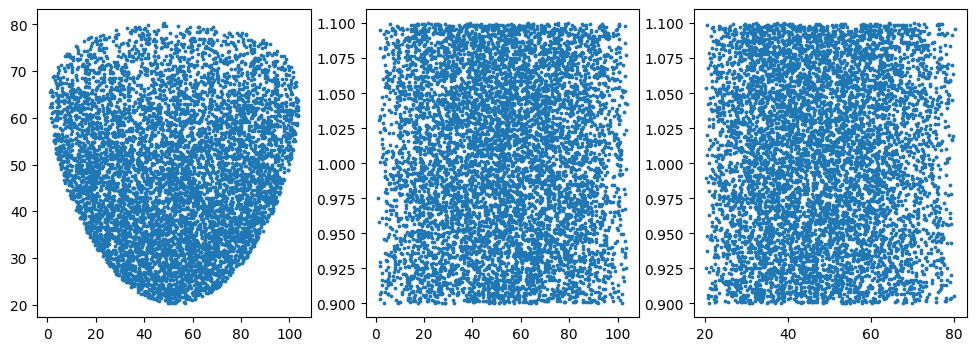

In [20]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].scatter(
    rec_data[1].data['RA'][::100],
    rec_data[1].data['DEC'][::100],
    s=3
)

axs[1].scatter(
    rec_data[1].data['RA'][::100],
    rec_data[1].data['REDSHIFT'][::100],
    s=3
)

axs[2].scatter(
    rec_data[1].data['DEC'][::100],
    rec_data[1].data['REDSHIFT'][::100],
    s=3
)